# Gap-filling head time series using Pastas

*Raoul Collenteur, Hydroconsult, 2026*

In [2]:
import pandas as pd
import pastas as ps
import matplotlib.pyplot as plt

ps.show_versions()

Pastas     : 2.0.0
Python     : 3.13.11
Numpy      : 2.4.6
Pandas     : 3.0.3
Scipy      : 1.17.1
Matplotlib : 3.10.9
Numba      : 0.65.1



In [18]:
head = pd.read_csv(
    "data/head_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()

# Create a gap in the head data
head_gap = head.copy()
head_gap.loc["1999"] = pd.NA
head_gap = head_gap.dropna()

prec = pd.read_csv(
    "data/rain_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()
evap = pd.read_csv(
    "data/evap_nb1.csv", parse_dates=["date"], index_col="date"
).squeeze()

# data = ps.load_dataset("collenteur_2019")
# head = data["head"].squeeze()

# head_gap = head.iloc[::14].copy()
# head_gap.loc["2007"] = pd.NA
# head_gap = head_gap.dropna()
# prec = data["rain"].asfreq("D").fillna(0)
# evap = data["evap"].asfreq("D").interpolate()

<Axes: xlabel='date'>

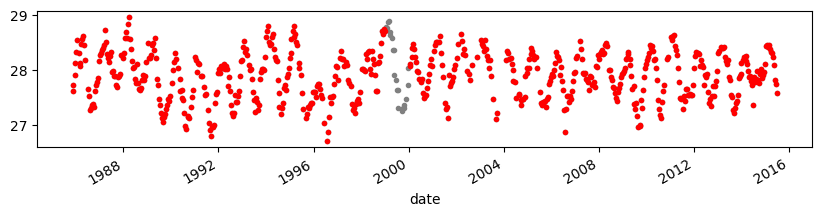

In [19]:
head.plot(marker=".", color="gray", linestyle="None", label="head", figsize=(10, 2))
head_gap.plot(marker=".", color="red", linestyle="None", label="head with gap")

In [20]:
ml = ps.Model(head_gap)
sm = ps.RechargeModel(prec=prec, evap=evap, rfunc=ps.Exponential(), name="rch")
ml.add_stressmodel(sm)
ml.solve()
ml.add_noisemodel(ps.ArNoiseModel())
ml.solve(initial=False)

Fit report head                     Fit Statistics
nfev     11                     EVP          93.64
nobs     623                    R2            0.94
noise    False                  RMSE          0.11
tmin     1985-11-14 00:00:00    AICc      -2781.53
tmax     2015-06-28 00:00:00    BIC       -2763.85
freq     D                      Obj           3.54
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No

Parameters (4 optimized)
               optimal     initial  vary
rch_A       675.746954  215.674528  True
rch_a       175.277495   10.000000  True
rch_f        -1.433342   -1.000000  True
constant_d   28.066083   27.895650  True
Fit report head                     Fit Statistics
nfev     16                     EVP          93.42
nobs     623                    R2            0.93
noise    True                   RMSE          0.11
tmin     1985-11-14 00:00:00    AICc      -3172.97
tmax     2015-06-28 00:00:00    BIC       -3150.90
freq

/Users/raoulcollenteur/Github/pastas/pastas/pastas/decorators.py:278: FutureWarning: From Pastas 2.4, the first argument of RechargeModel needs to be a Pastas Model. Please provide the model as the first argument: RechargeModel(model=ml, ...).
  warn(message=msg % (self._name, self._name), category=FutureWarning)
/Users/raoulcollenteur/Github/pastas/pastas/pastas/decorators.py:71: FutureWarning: add_stressmodel is deprecated and will not be available from Pastas version >= 2.4.0. Stressmodels are now added by adding the Pastas Model as the first argument during stressmodel initialization (i.e., ps.StressModel(model=ml, *args))
  warn(message=msg, category=FutureWarning)
/Users/raoulcollenteur/Github/pastas/pastas/pastas/decorators.py:278: FutureWarning: From Pastas 2.4, the first argument of ArNoiseModel needs to be a Pastas Model. Please provide the model as the first argument: ArNoiseModel(model=ml, ...).
  warn(message=msg % (self._name, self._name), category=FutureWarning)
/Users/r

<Axes: xlabel='date', ylabel='Head'>

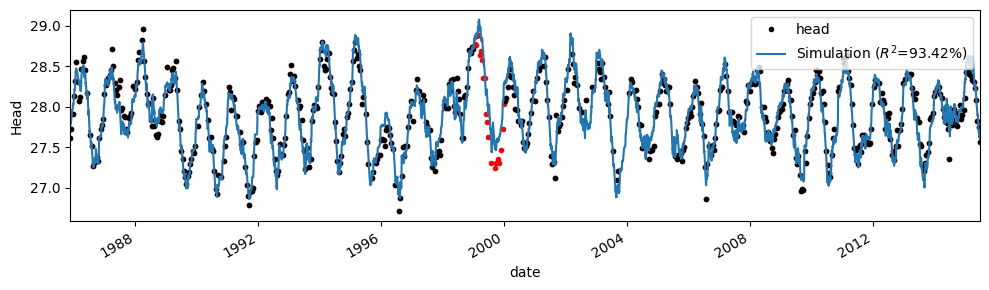

In [21]:
ax = ml.plot(figsize=(10, 3))
head.plot(marker=".", color="red", linestyle="None", label="head", ax=ax, zorder=-1)

In [22]:
head_filled = ps.gap_fill(
    head_gap.asfreq("D"), ml, tmin=head.index[0], tmax=head.index[-1], alpha=0.05
)

Text(0, 0.5, 'head [m]')

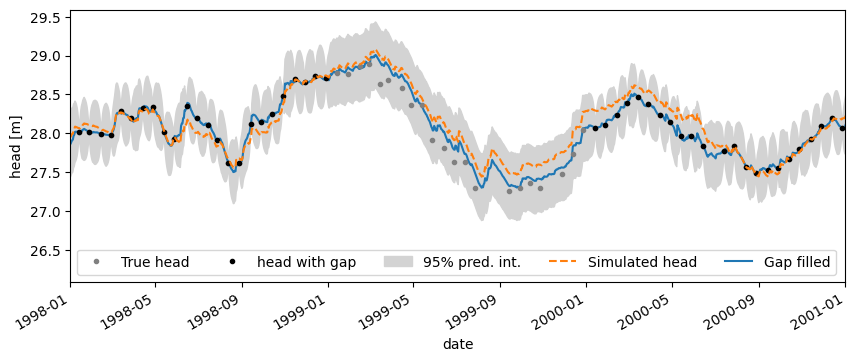

In [30]:
ax = head.plot(
    marker=".", color="gray", linestyle="None", label="True head", figsize=(10, 4)
)
head_gap.plot(marker=".", color="k", linestyle="None", label="head with gap")
# Fill between
ax.fill_between(
    head_filled.index,
    head_filled["lower"],
    head_filled["upper"],
    color="lightgray",
    label="95% pred. int.",
    zorder=-2,
)
ml.simulate().plot(ax=ax, color="C1", linestyle="--", label="Simulated head")
head_filled.loc[:, "head_filled"].plot(ax=ax, zorder=-1, label="Gap filled")
plt.xlim("1998", "2001")
# plt.xlim("2005", "2010")
plt.legend(ncol=5)
plt.ylabel("head [m]")

In [9]:
head_filled.iloc[:100].plot(linestyle="-")
head  # .iloc[: head_filled.iloc[:100].index[-1]].plot()

NameError: name 'head_filled' is not defined

In [ ]:
ml.noise().std()

np.float64(0.07852838992319748)